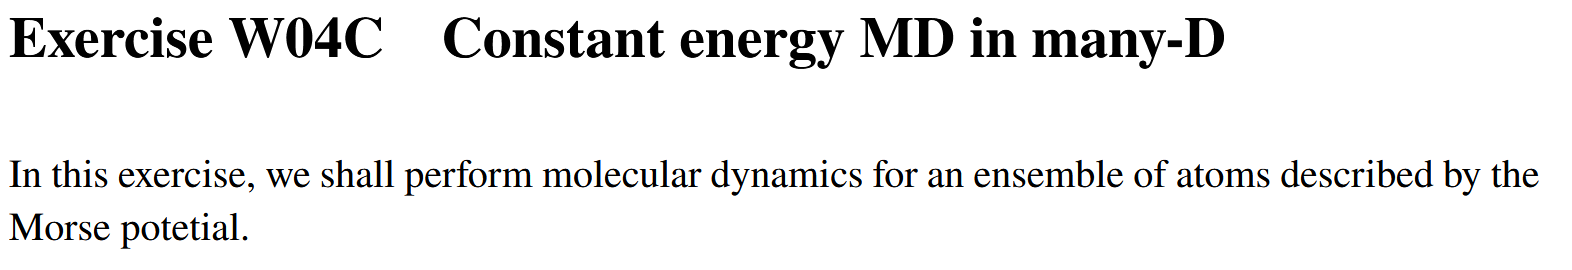
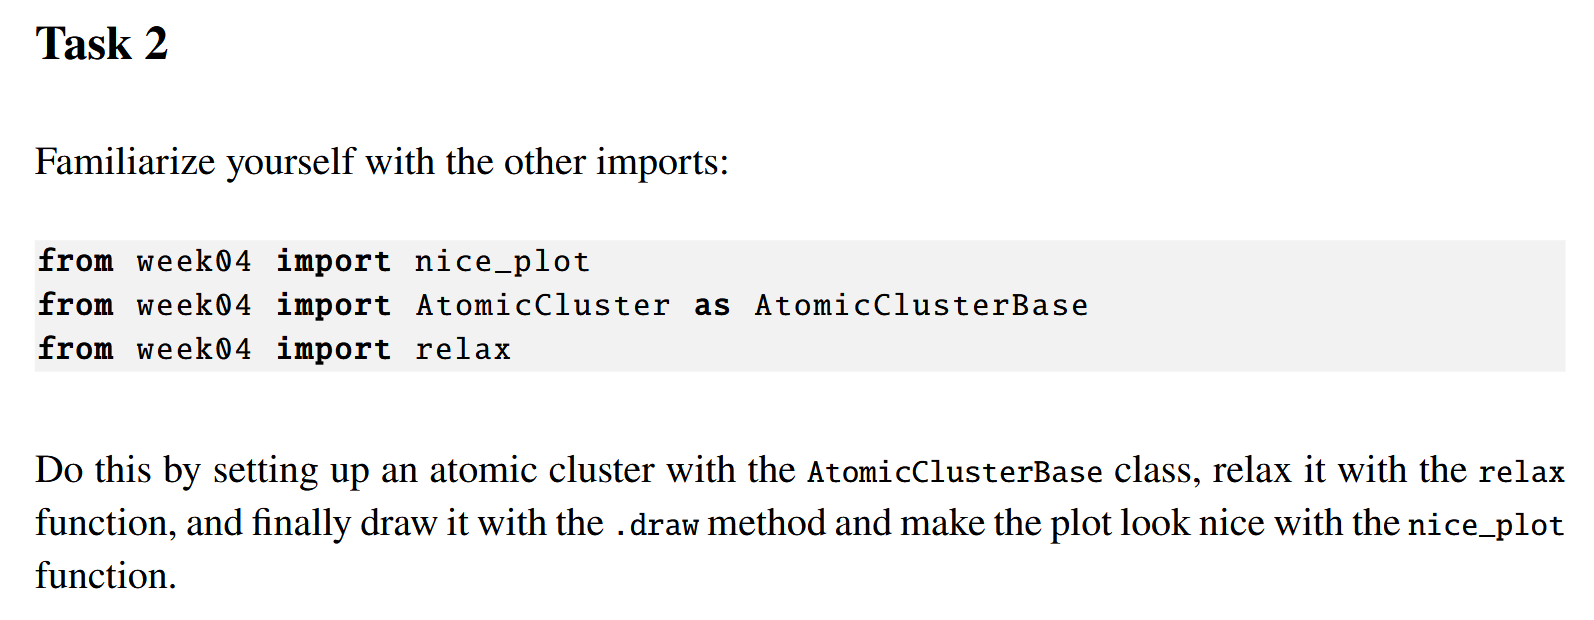

E(pos) = -1.5 should be -1.5


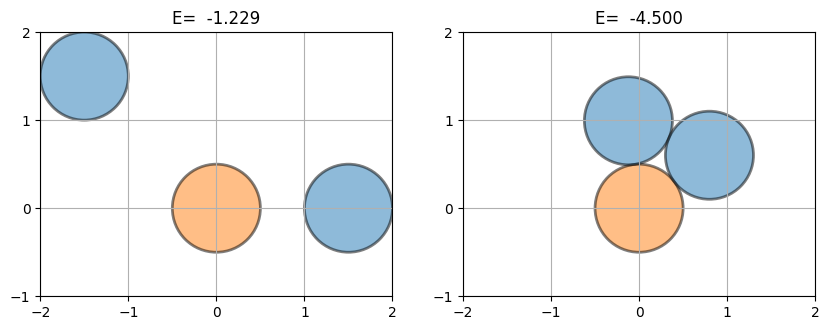

In [25]:
from week04 import *
morse = Morse()
pos = [[0,0], [1,0]]
print(f'E(pos) = {float(morse.potential_energy(pos))} should be -1.5') 

pos = [[0,0], [-1.5, 1.5], [1.5, 0]]
static = [True, False, False]
cluster = AtomicCluster(morse, pos=pos, static=static)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
cluster.draw(ax[0])
relax(cluster)
cluster.draw(ax[1])

nice_plot(ax[0])
nice_plot(ax[1])

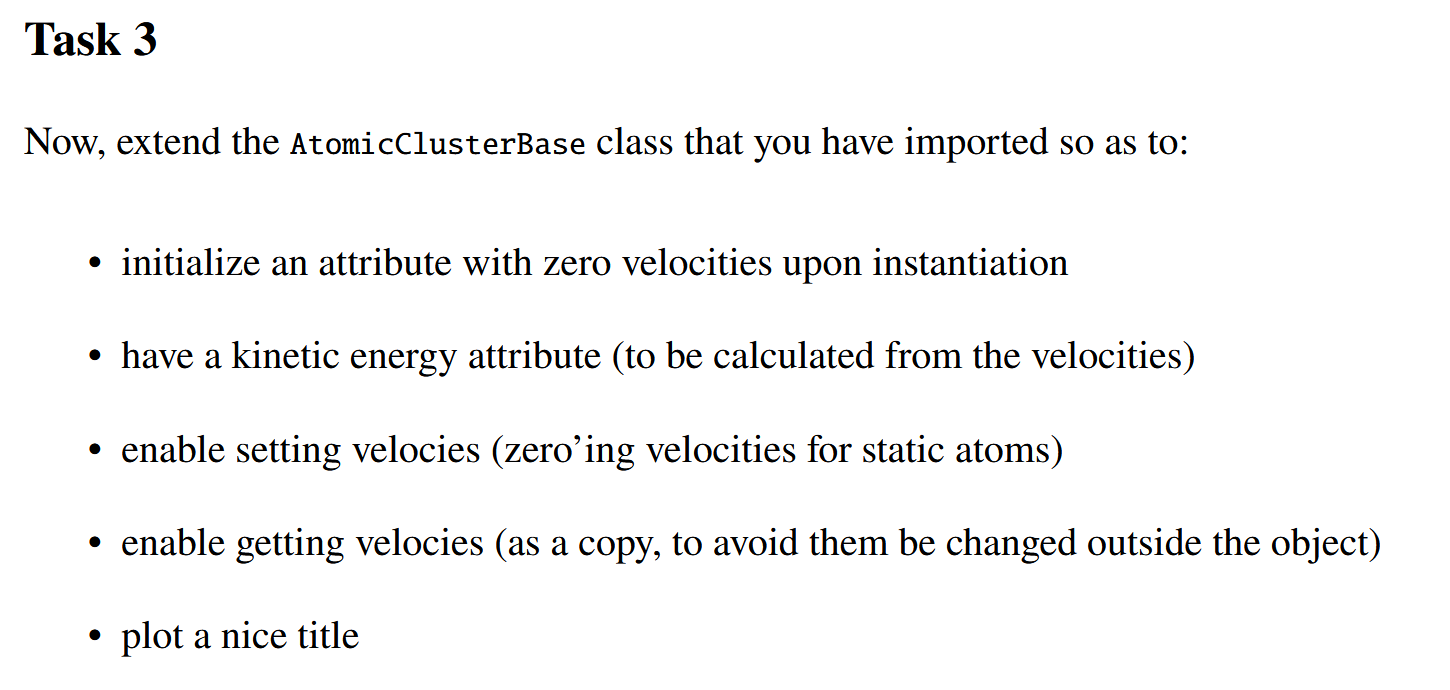

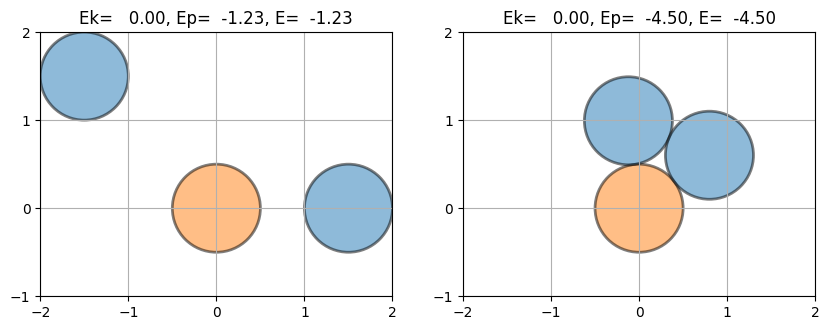

In [26]:
class AtomicCluster(AtomicCluster):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.v = np.zeros(self.pos.shape)

    @property
    def K(self):
        return 0.5 * np.sum(self.v**2) # assume m=1

    def get_velocitys(self):
        return self.v.copy()
    
    def set_velocitys(self, v):
        self.v = v

    def draw_title(self, ax):
        ek = self.K
        ep = self.potential_energy
        etot = ek+ep
        ax.set_title(f'Ek={ek:7.2f}, Ep={ep:7.2f}, E={etot:7.2f}')

cluster = AtomicCluster(morse, pos=pos, static=static)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
cluster.draw(ax[0])
relax(cluster)
cluster.draw(ax[1])

nice_plot(ax[0])
nice_plot(ax[1])


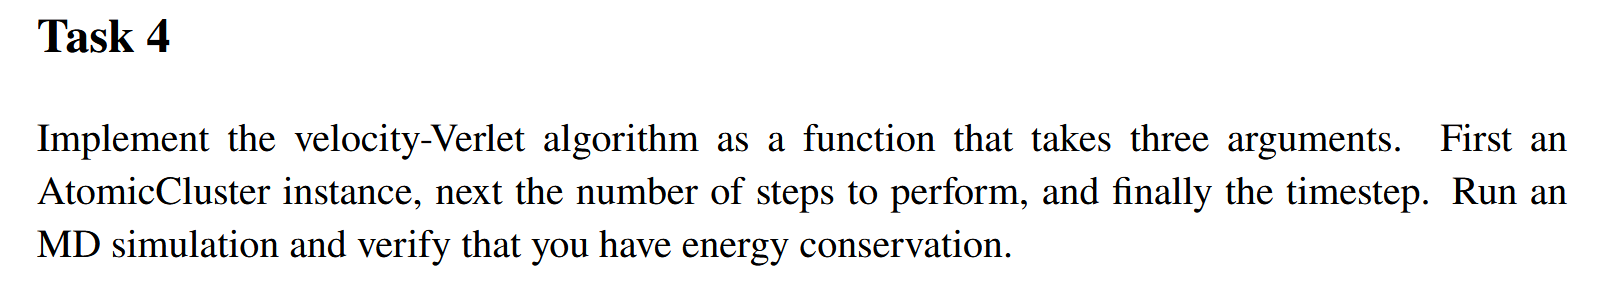

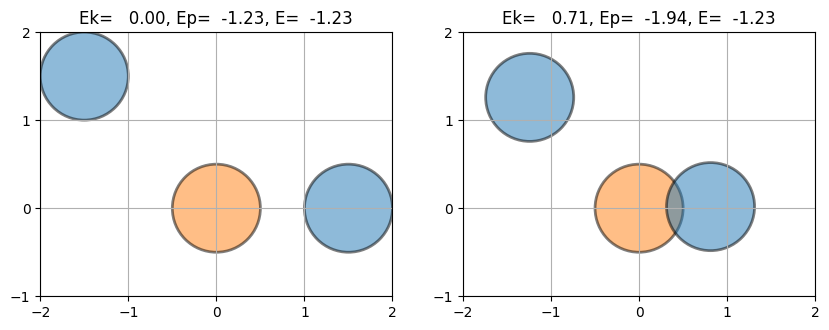

In [28]:
def velocity_verlet(cluster, N=100, dt=0.01):
    rs = []
    energies = []
    for _ in range(N):
        r = cluster.get_positions().copy()
        v = cluster.get_velocitys().copy()
        a_t = cluster.forces.copy() # assume m=1

        r += v*dt + 0.5*a_t*dt**2
        cluster.set_positions(r)

        a_dt = cluster.forces.copy() # assume m=1

        v += 0.5* (a_t + a_dt) * dt
        cluster.set_velocitys(v)

        rs.append(r.copy())
        energies.append(cluster.potential_energy + cluster.K)

    return rs

calc = ModifiedMorse()
cluster = AtomicCluster(calc, pos=pos, static=static)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
cluster.draw(ax[0])
velocity_verlet(cluster)
cluster.draw(ax[1])

nice_plot(ax[0])
nice_plot(ax[1])